In [312]:
import pandas as pd

### Import dataset

In [313]:
df = pd.read_csv('adult.csv', na_values='?')
df.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Understanding the data

In [314]:
df.shape

(48842, 15)

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [316]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [317]:
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [318]:
df.duplicated().sum()

np.int64(52)

In [319]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

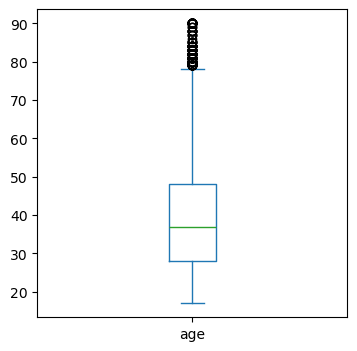

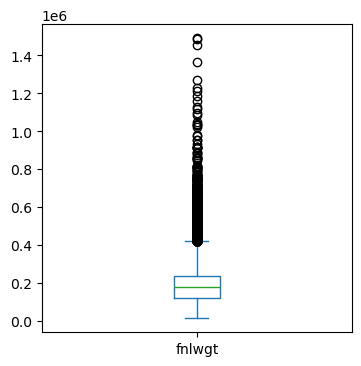

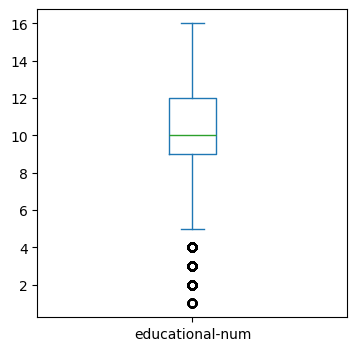

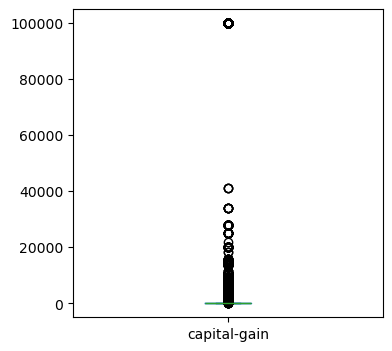

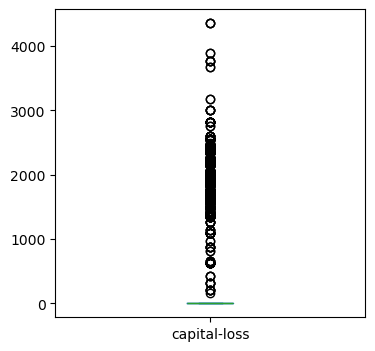

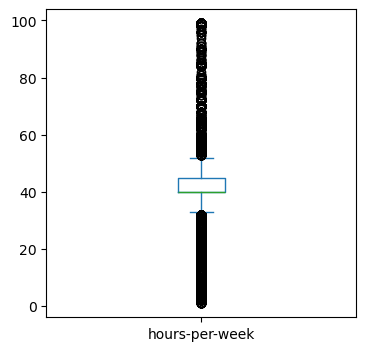

In [320]:
# Checking outliers in numeric column
import matplotlib.pyplot as plt
numeric_columns = df.select_dtypes(include='number').columns

for cols in numeric_columns:
    df[cols].plot(kind='box', figsize=(4,4))
    plt.show()

All of the outliers are kept because all of them are most likely to be valid outlier

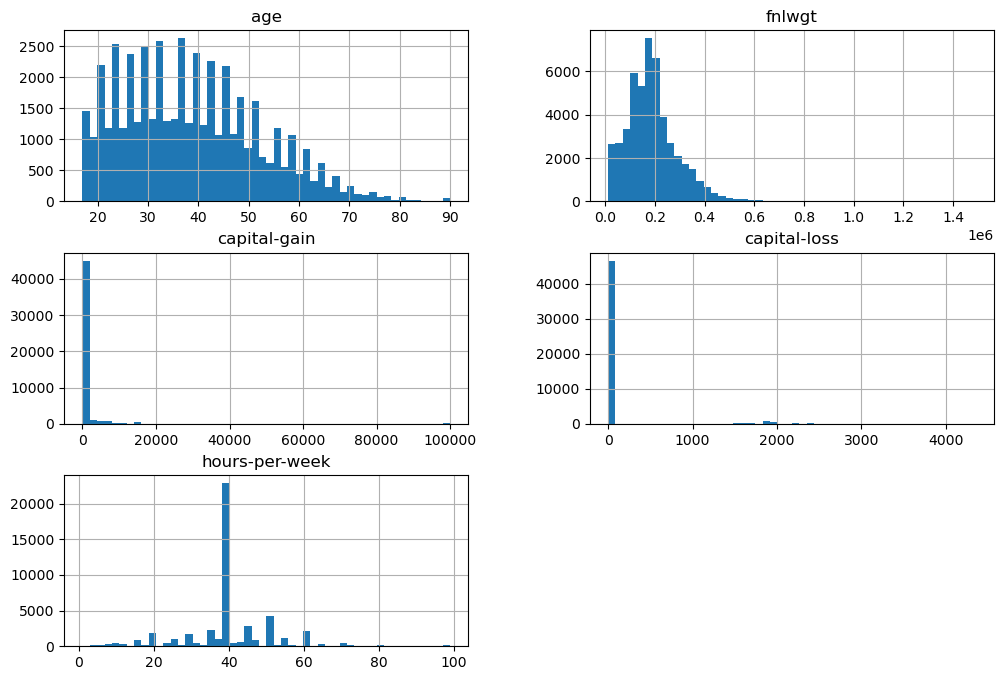

In [321]:
import matplotlib.pyplot as plt
df[['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']].hist(figsize=(12,8), bins=50)
plt.show()

In [322]:
# Log transform for capital gain and capital loss, because both column are heavily right skewed
import numpy as np
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])

In [323]:
df['income_encoded'] = df['income'].map({'>50K': 1, '<=50K': 0})

In [324]:
df[df['workclass'].isna()]['occupation'].isna().sum()

np.int64(2795)

In [325]:
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')

'?' to "Unknown": missingness in workclass/occupation is likely MNAR (tied to unemployment status), so treating it as its own category can preserve the signal

### Train test split

In [326]:
from sklearn.model_selection import train_test_split

In [327]:
df.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,capital-gain-log,capital-loss-log,income_encoded
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0.0,0.0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0.0,0.0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,0.0,0.0,1


In [328]:
# Seperate X and y
X = df.drop(columns=['fnlwgt', 'education', 'capital-gain', 'capital-loss', 'income', 'income_encoded'])
y = df['income_encoded']

In [329]:
X.head(3)

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,capital-gain-log,capital-loss-log
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,0.0,0.0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,0.0,0.0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,0.0,0.0


In [330]:
X.shape

(48790, 12)

In [331]:
y.head(3)

0    0
1    0
2    1
Name: income_encoded, dtype: int64

In [332]:
y.shape

(48790,)

In [333]:
# Split data into training and test set 8:2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

In [334]:
X_train.shape

(39032, 12)

In [335]:
y_train.shape

(39032,)

In [336]:
X_test.shape

(9758, 12)

In [337]:
y_test.shape

(9758,)

### Data preprocessing and building pipeline

In [338]:
X.head(3)

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,capital-gain-log,capital-loss-log
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,0.0,0.0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,0.0,0.0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,0.0,0.0


In [339]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

numeric_features = ['age', 'educational-num', 'hours-per-week', 'capital-gain-log', 'capital-loss-log']
categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

categoric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # For imputing native-country
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_features),
    ('cat', categoric_transformer, categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression(max_iter=1000))
])

### Training model and results

In [340]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['age', 'educational-num',
                                                   'hours-per-week',
                                                   'capital-gain-log',
                                                   'capital-loss-log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native-country'])])),
                ('regressor', LogisticRegression(max_iter=1000))])

In [341]:
y_pred = model.predict(X_test)

In [342]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8774    0.9295    0.9027      7417
           1     0.7249    0.5886    0.6497      2341

    accuracy                         0.8477      9758
   macro avg     0.8012    0.7591    0.7762      9758
weighted avg     0.8408    0.8477    0.8420      9758



### Conclusion

The logistic regression model achieved 84.77% overall accuracy on the test set, but performance was imbalanced across classes. For the majority class (income <=50K, number of data on test set=7417), the model performed strongly with precision 0.8774, recall 0.9295, and F1-score 0.9027. For the minority class (income >50K, number of data on test set=2341), performance was notably weaker with precision 0.7249, recall 0.5886, and F1-score 0.6497.